# Read in data

In [ ]:
import pandas as pd
import numpy as np
from itertools import product, combinations
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt
from pingouin import ttest
from pylatexenc.latexencode import unicode_to_latex as text2latex
from scipy import stats


sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))

from src.helpers import make_aesthetic, cat_stats
from src.statsmodels_handler import StatsmodelsHandler, clean_var_name_from_formula
import random

random.seed(42)
np.random.seed(42)

mypal = make_aesthetic()


def make_bold(x):
	"""
	This function is used to make part of the title bold like as a subtitle.
	Basically, it's using latex to render a (sub)string bold in matplot.
	But make_aesthetic() should handle using Arial for math font,
	so it won't look weird.
	>>> full_title = f"{make_bold("Regression Coefficients of Estimated Prevalence From Multiverse")}\n(Baseline is raw data with no weighting and no dropping)"

	"""
	#
	words = x.split()
	words = ' \\ '.join([w for w in words])  # Escape backslash properly
	bold_str = f"$\\bf{{{words}}}$"  # Correctly format the f-string
	return bold_str

def did_use(x):
    if "never" in x.lower():
        return 0
    else:
        return 1

def short_domain(x):
    if "convention" in x.lower():
        return "conventional"
    elif "moral" in x.lower():
        return "moral"
    elif "personal" in x.lower():
        return "personal"
    else:
        return "other"


def make_df():
    df = pd.read_csv("../data/qualtrics_experiments/desc_norms_interface [typing]_August 23, 2025_20.20.csv")
    # print(sorted(df.columns))
    df = df.iloc[2:]
    df = df.query("DistributionChannel=='anonymous'") # this will remove reponses from using preview link

    data_pts = []
    for i, row in df.iterrows():
        # non_loop_merge_vars
        base_pt = {
            "pid": row['ResponseId'],
            "progress": row['Progress'],
            "duration": float(row['Duration (in seconds)'])/60,
            "finished": row['Finished'],
            "feedback": row['feedback'],
            "llm_usage": row['dv_llm_usage'],
            "usage_convention": row['dv_usage_convention'],
            "usage_moral": row['dv_usage_moral'],
            "usage_personal": row['dv_usage_personal'],
            "llm_usage_binary": did_use(row['dv_llm_usage']),
            "usage_convention_binary": did_use(row['dv_usage_convention']),
            "usage_moral_binary": did_use(row['dv_usage_moral']),
            "usage_personal_binary": did_use(row['dv_usage_personal']),
        }

        # loop and merge columns:
        for i in range(1, 60):
            pre = float(row.get(f'{i}_lm_pre_11'))
            post =float( row.get(f'{i}_lm_post_11'))
            qual = row.get(f'{i}_lm_qual')
            if pd.notnull(pre) and pd.notnull(post):
                data_pt = base_pt.copy()
                data_pt['idx'] = i
                data_pt['pre'] = pre
                data_pt['post'] = post
                data_pt['qual'] = qual
                data_pts.append(data_pt)


    # We get a long dataframe with one row per trial per person
    df = pd.DataFrame(data_pts)


    # Merge in metadata
    #############################################
    #############################################
    meta_df = pd.read_csv("../data/clean/ai_rot_stimuli_new_prompt.csv")
    df = df.merge(meta_df, on='idx', how='left')
    #############################################
    #############################################

    # Clean and process
    #############################################
    #############################################

    # Distance stuff
    df['pre_distance'] = np.abs(df['pre'] - df['rating'])
    df['post_distance'] = np.abs(df['post'] - df['rating'])
    df['change_distance'] = df['pre_distance'] - df['post_distance']

    # Domain cleaning
    df['domain'] = df['domain'].map(short_domain)

    # Duration bucketing
    durations = df.drop_duplicates(subset=['pid'])['duration'].to_list()
    mean_duration = np.mean(durations)
    sd_duration = np.std(durations)
    low_threshold = mean_duration - 2*sd_duration
    df['low_duration'] = (df['duration'] < low_threshold)
    print("Number of low duration people")
    print(df['low_duration'].value_counts())


    # Usage cleaning
    usage_map = {
       "No - never used": 0,
       "Yes - less often than several times a week": 1,
       "Yes - several times a week": 2,
       "Yes - about once a day": 3,
       "Yes - several times a day": 4
    }
    for var in ['usage_personal', 'usage_moral', 'usage_convention']:
        df[f"{var}_int"] = df[var].map(usage_map)
    df['usage_sum'] = df[['usage_personal_int', 'usage_moral_int', 'usage_convention_int']].sum(axis=1)

    df.to_csv("../data/qualtrics_experiments/desc_norms_init_norm_pilot_long.csv", index=False)

    return df
    #############################################
    #############################################

df = make_df()

# Basic data quality checks

In [ ]:
from src.helpers import array_stats
from scipy.stats import ttest_ind, mannwhitneyu

print("Durations")
durations =  array_stats(df.drop_duplicates(subset=['pid'])['duration'].values, include_ci=True)
sns.regplot(data=df, x='duration', y='change_distance', x_bins=5)



 # Descriptives of change

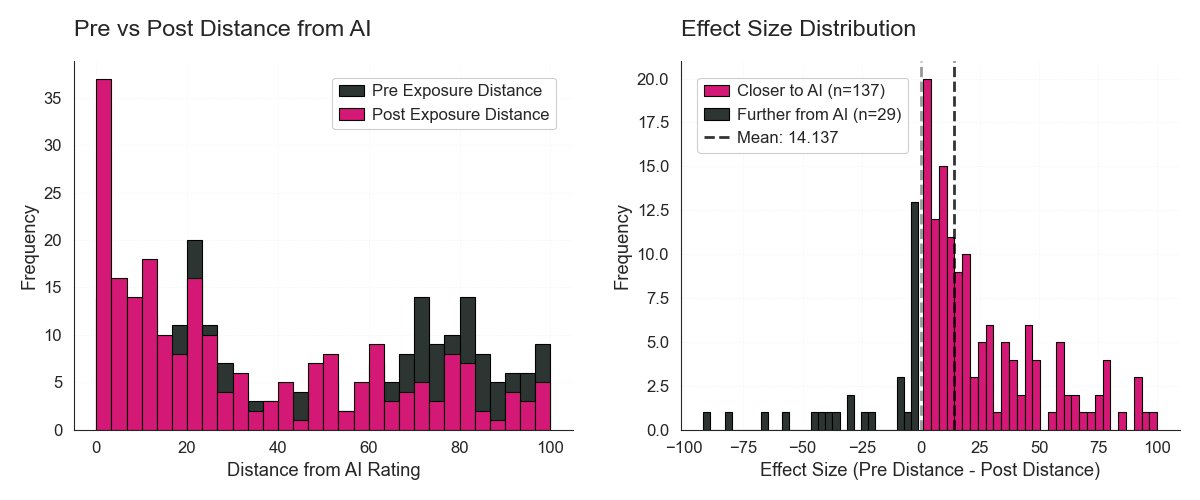


    The mean effect (pre-distance minus post-distance) was 14.14 (SD = 28.42) on an agreement scale of 0-100, with a Cohen's dz of 0.50 (95% CI [0.37, 0.63]) and Wilcoxon signed-rank test W = 1886.5, p = 4.1e-16. In 61% of cases, participants moved closer to the AI rating, while in 13% of cases they moved further away, and in 27% of cases there was no change. The mixed model estimate of the effect (crossed random intercepts for participants and items) was beta = 14.00 (95% CI [8.47, 19.54])


In [221]:
import matplotlib.pyplot as plt
import numpy as np
from src.helpers import array_stats

mypal = make_aesthetic(font_scale=1.2)
effect_size = df['pre_distance'] - df['post_distance']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#################################################################
# Pre_distance and post_distance as overlaid histograms
#################################################################
ax1 = axes[0]
ax1.hist(df['pre_distance'], bins=30, alpha=1, label='Pre Exposure Distance',  edgecolor='black')
ax1.hist(df['post_distance'], bins=30, alpha=1, label='Post Exposure Distance', edgecolor='black')
ax1.set_xlabel('Distance from AI Rating')
ax1.set_ylabel('Frequency')
ax1.set_title('Pre vs Post Distance from AI')
ax1.legend()
ax1.grid(True, alpha=0.3)

#################################################################
# Distribution of effect sizes
#################################################################
ax2 = axes[1]
closer_to_ai = effect_size[effect_size > 0]
further_from_ai = effect_size[effect_size < 0]

ax2.hist(closer_to_ai, bins=30, alpha=1, label=f'Closer to AI (n={len(closer_to_ai)})',
color=mypal[1], edgecolor='black')
ax2.hist(further_from_ai, bins=30, alpha=1, label=f'Further from AI (n={len(further_from_ai)})',
         color=mypal[0], edgecolor='black')
ax2.axvline(0, color='gray', linestyle='--', alpha=0.8, linewidth=2)
ax2.axvline(effect_size.mean(), color='black', linestyle='--', alpha=0.8, linewidth=2,
            label=f'Mean: {effect_size.mean():.3f}')

ax2.set_xlabel('Effect Size (Pre Distance - Post Distance)')
ax2.set_ylabel('Frequency')
ax2.set_title('Effect Size Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)


plt.show()


######################################
# Statistics
######################################

def get_mixed_model_estimate(data):
    formula = 'change_distance ~ 1'
    data['dummy'] = 1
    model = MixedLM.from_formula(formula, data=data,
                             groups='dummy',
                             vc_formula={'id1': "0 + C(pid)",
                                         'id2': "0 + C(rot)"}
                                         ).fit()
    mixed_model_estimate = model.fe_params['Intercept']
    ci = model.conf_int()
    mixed_model_low, mixed_model_high = ci.loc['Intercept']
    return mixed_model_estimate, mixed_model_low, mixed_model_high

def bootstrap_dz(data, n_bootstraps=10000):
    boot_dz = []
    n = len(data)
    for i in range(n_bootstraps):
        sample = np.random.choice(data, size=n, replace=True)
        mean_diff = np.mean(sample)
        sd_diff = np.std(sample, ddof=1)
        if sd_diff != 0:
            boot_dz.append(mean_diff / sd_diff)
    return np.percentile(boot_dz, [2.5, 97.5])

def compute_change_metrics(pre, post):
    effect_size = pre - post
    mean_diff = effect_size.mean()
    sd_diff = effect_size.std()
    mixed_model_estimate, mixed_model_low, mixed_model_high = get_mixed_model_estimate(df)
    cohens_dz = mean_diff / sd_diff
    ci_lower, ci_upper = bootstrap_dz(effect_size)
    moved_closer = effect_size > 0
    moved_further = effect_size < 0
    no_change = effect_size == 0
    wilcox_w = stats.wilcoxon(pre, post)

    # Calculate percentages
    n = len(effect_size)
    percent_closer = moved_closer.sum() / n
    percent_further = moved_further.sum() / n
    percent_no_change = no_change.sum() / n

    data =  {
        "mean_diff": mean_diff,
        "sd_diff": sd_diff,
        "cohens_dz": cohens_dz,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "moved_closer": moved_closer,
        "moved_further": moved_further,
        "no_change": no_change,
        "wilcox_w": wilcox_w.statistic,
        "wilcox_p": wilcox_w.pvalue
    }
    stats_str = f"""
    The mean effect (pre-distance minus post-distance) was {mean_diff:.2f} (SD = {sd_diff:.2f}) on an agreement scale of 0-100, with a Cohen's dz of {cohens_dz:.2f} (95% CI [{ci_lower:.2f}, {ci_upper:.2f}]) and Wilcoxon signed-rank test W = {wilcox_w.statistic}, p = {wilcox_w.pvalue:.1e}. In {percent_closer*100:.0f}% of cases, participants moved closer to the AI rating, while in {percent_further*100:.0f}% of cases they moved further away, and in {percent_no_change*100:.0f}% of cases there was no change. The mixed model estimate of the effect (crossed random intercepts for participants and items) was beta = {mixed_model_estimate:.2f} (95% CI [{mixed_model_low:.2f}, {mixed_model_high:.2f}])"""
    print(stats_str)
    return data

metrics = compute_change_metrics(df['pre_distance'], df['post_distance'])



# By factors

## Descriptive plots

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.formula.api as smf
from statsmodels.regression.mixed_linear_model import MixedLM
import pandas as pd
import warnings
warnings.filterwarnings("ignore")


#############################################
# Grid plot by factors
#############################################
mypal = make_aesthetic(font_scale=1.2)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
mypal = make_aesthetic(font_scale=1.2)
factors = ['domain', 'agreement_condition', 'prompt_condition']
factor_titles = ['Domain', 'Agreement Condition', 'Prompt Condition']

for i, (factor, title) in enumerate(zip(factors, factor_titles)):
    ax = axes[i]

    sns.pointplot(x=factor, y='change_distance', data=df, palette=mypal,
                 capsize=0.1, errwidth=2, ax=ax)

    sns.stripplot(x=factor, y='change_distance', data=df, palette=mypal,
                 alpha=0.4, size=3, ax=ax)

    ax.axhline(y=0, color='k', linestyle='--', alpha=0.7)

    labels = [label.get_text().replace('_', ' ').title() for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels, rotation=45)

    ax.set_title(f"Effect Size by {title}")
    ax.set_ylabel("Effect size")
    ax.set_xlabel(title)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
#############################################
#############################################

## Mixed effects model

In [ ]:
# Baseline model --- crossed random effects for person and stimulus
##########################################################################################
##########################################################################################

# https://github.com/statsmodels/statsmodels/issues/9279
formula = 'change_distance ~ C(domain, Treatment(reference="conventional")) + C(agreement_condition, Treatment(reference="medium_agreement")) + C(prompt_condition, Treatment(reference="Debate"))'
df['dummy'] = 1
model = MixedLM.from_formula(formula, data=df,
                             groups='dummy',
                             vc_formula={'id1': "0 + C(pid)",
                                         'id2': "0 + C(rot)"}
                                         )

result = model.fit()
print(result.summary())
from src.statsmodels_handler import StatsmodelsHandler, clean_var_name_from_formula
handler = StatsmodelsHandler(result)
handler.to_latex()
handler.plot(clean_var_name=clean_var_name_from_formula)
plt.xlabel("Effect (Change in Distance to AI)")
plt.ylabel("")
plt.title("Regression Coefficients with 95% CIs")
plt.show()

# Where are these changes coming from?

## Transition matrices

In [ ]:
from src.helpers import make_aesthetic
mypal = make_aesthetic(font_scale=1.2)

def get_bucket_number(x):
    x = x.split("\n")[0][1:]
    return x

def is_extreme(x):
    return x < 10 or x > 90

def bucket_label(x, n_bins):
    bins = np.linspace(0, 100, n_bins + 1)
    labels = [f"B{i+1}\n({int(bins[i])}-{int(bins[i+1])})" for i in range(n_bins)]
    return pd.cut([x], bins=bins, labels=labels, include_lowest=True, ordered=True)[0]

df['pre_extreme'] = df['pre'].apply(is_extreme)
df['post_extreme'] = df['post'].apply(is_extreme)

####################################
# Transition matrix of extremes
####################################
sns.heatmap(
    pd.crosstab(df['pre_extreme'], df['post_extreme'], normalize='index'),
    annot=True, fmt=".2f", cmap="binary"
)
plt.xlabel("Post Extreme (<=10 or >=90)")
plt.ylabel("Pre Extreme (<=10 or >=90)")
plt.title(f"{make_bold("Transition Matrix of Extreme Ratings")}\nRows sum to 1 (horizontally)")
plt.show()


####################################
# Transition matrix of pre/post buckets
####################################
N_BINS=4
df['pre_bucket'] = df['pre'].apply(bucket_label, n_bins=N_BINS)
df['post_bucket'] = df['post'].apply(bucket_label, n_bins=N_BINS)
sns.heatmap(
    pd.crosstab(df['pre_bucket'], df['post_bucket'], normalize='index'),
    annot=True, fmt=".2f", cmap="binary"
)
plt.xlabel("Post Bucket")
plt.ylabel("Pre Bucket")
plt.title(f"{make_bold("Transition Matrix of Rating Buckets")}\nRows sum to 1 (horizontally)")
####################################

In [ ]:
pd.crosstab(df['pre_bucket'], df['post_bucket'])

## Effect size by (pre-exposure, AI rating) bins

In [ ]:
def get_bucket_number(x):
    x = x.split("\n")[0][1:]
    return x

N_BINS=3
df['pre_bucket'] = df['pre'].apply(bucket_label, n_bins=N_BINS)
df['post_bucket'] = df['post'].apply(bucket_label, n_bins=N_BINS)
df['pre_bucket_int'] = df['pre_bucket'].apply(get_bucket_number).astype(int)
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='pre_bucket_int', y='change_distance', color='gray')
# sns.lineplot(data=df, x='pre_bucket', y='change_distance', color='gray')
plt.xlabel("Pre Bucket")
plt.ylabel("Effect")


In [ ]:
N_BINS = 5

df['rating_bucket'] = df['rating'].apply(bucket_label, n_bins=N_BINS)
df['rating_bucket_int'] = df['rating_bucket'].apply(get_bucket_number).astype(int)

df['pre_bucket'] = df['pre'].apply(bucket_label, n_bins=N_BINS)
df['pre_bucket_int'] = df['pre_bucket'].apply(get_bucket_number).astype(int)

# Get the sorted bucket categories
rating_order = [x for _, x in sorted(zip(df['rating_bucket_int'], df['rating_bucket'].astype(str).unique()), key=lambda t: int(get_bucket_number(t[1])))]
pre_order = [x for _, x in sorted(zip(df['pre_bucket_int'], df['pre_bucket'].astype(str).unique()), key=lambda t: int(get_bucket_number(t[1])))]



fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Mean of effects
heatmap_mean = df.pivot_table(index='rating_bucket', columns='pre_bucket', values='change_distance', aggfunc='mean')
heatmap_mean = heatmap_mean.reindex(index=rating_order, columns=pre_order)
sns.heatmap(heatmap_mean, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_xlabel("Pre-Exposure Rating")
axes[0].set_ylabel("AI Rating")
axes[0].set_title(f"{make_bold('Mean Effect by AI Rating and Pre-Exposure Rating')}\nMean Effect Sizes in Each Cell")

# Sum of effects
heatmap_sum = df.pivot_table(index='rating_bucket', columns='pre_bucket', values='change_distance', aggfunc='sum')
heatmap_sum = heatmap_sum.reindex(index=rating_order, columns=pre_order)
sns.heatmap(heatmap_sum, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_xlabel("Pre-Exposure Rating")
axes[1].set_ylabel("AI Rating")
axes[1].set_title(f"{make_bold('Total Effect by AI Rating and Pre-Exposure Rating')}\nSum of Effect Sizes in Each Cell")


plt.show()

## Denormalization vs Normalization

In [ ]:
from scipy.stats import permutation_test

def cohens_d(x, y):
   nx, ny = len(x), len(y)
   pooled_std = np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / (nx+ny-2))
   return (np.mean(x) - np.mean(y)) / pooled_std

def statistic(x, y):
   return np.mean(x) - np.mean(y)

df['convince_type'] = np.where(df['rating'] < df['pre'], "Denormalize", "Normalize")
denorm = df[df['convince_type'] == 'Denormalize']['change_distance']
norm = df[df['convince_type'] == 'Normalize']['change_distance']
cohens_d = cohens_d(denorm, norm)
res = permutation_test((denorm, norm), statistic, n_resamples=10000, alternative='two-sided', random_state=42)
plt.figure(figsize=(9, 6))
sns.pointplot(data=df, x='convince_type', y='change_distance')

plt.ylabel("Effect")
plt.xlabel("Argument Type")
plt.title(f"{make_bold('LLM Denormalization vs Normalization')}\nDenormalization is where LLM argues the rule of thumb is less\nappropriate than pre-exposure and vice versa.")
stats_dz_str = f"Difference = {res.statistic:.2f}, Cohen's d = {cohens_d:.2f}, p = {res.pvalue:.3f}"
plt.figtext(0.5, 0.8, stats_dz_str, ha="center", fontsize=10)
plt.show()

# Individual differences

In [ ]:
pid_cols = [c for c in df.columns if "usage" in c] + ["pid", "feedback"]

byp = (
    df.groupby(pid_cols)['change_distance']
      .agg(mean=np.mean, sd=np.std)
      .reset_index()
)
sns.scatterplot(data=df.sort_values(by=['change_distance']), y='pid', x='change_distance', hue='change_distance')


# How frequently do ppl use LLMs?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.stats.proportion import proportion_confint

from src.helpers import make_aesthetic


# Get color palette
mypal = make_aesthetic(font_scale=1.2)


# Create the any usage indicator
##################################################

byp['any_usage'] = ((byp['usage_personal_binary'] == 1) |
                   (byp['usage_moral_binary'] == 1) |
                   (byp['usage_convention_binary'] == 1)).astype(int)


# Get wilson CIs
##################################################
usage_vars = ['usage_personal_binary', 'usage_moral_binary', 'usage_convention_binary', 'any_usage']
labels = ['Personal', 'Moral', 'Conventional', 'Any SSL Usage']
summary_data = []
for var, label in zip(usage_vars, labels):
    count = byp[var].sum()
    total = len(byp)
    prop = count / total
    ci_low, ci_high = proportion_confint(count, total, method='wilson')

    summary_data.append({
        'usage_type': label,
        'proportion': prop,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'count': count,
        'total': total
    })

usage_df = pd.DataFrame(summary_data)
print(usage_df)


# Plot
##################################################
plt.figure(figsize=(10, 6))
bars = plt.bar(usage_df['usage_type'], usage_df['proportion'],
               color=mypal[:len(usage_df)], alpha=0.7)
errors = [usage_df['proportion'] - usage_df['ci_low'],
          usage_df['ci_high'] - usage_df['proportion']]
plt.errorbar(usage_df['usage_type'], usage_df['proportion'], yerr=errors,
             fmt='none', color='black', capsize=5)
for i, row in usage_df.iterrows():
    plt.text(i, row['ci_high'] + 0.02, f"{row['proportion']:.2f}\n[{row['ci_low']:.2f}, {row['ci_high']:.2f}]",
             ha='center', va='bottom', fontweight='bold')

plt.ylabel('Proportion Ever Used')
plt.axhline(y=0.66, color='red', linestyle='--', alpha=0.7, label="0.66 is current estimate from meta-analysis")
plt.legend(loc='lower right')
plt.title('Synthetic Social Learning Usage by Participants (95% Wilson CI)')
plt.ylim(0, 1)
plt.show()

In [ ]:
usage_map = {
   "No - never used": 0,
   "Yes - less often than several times a week": 1,
   "Yes - several times a week": 2,
   "Yes - about once a day": 3,
   "Yes - several times a day": 4
}

df['any_usage'] = ((df['usage_personal_binary'] == 1) |
                   (df['usage_moral_binary'] == 1) |
                   (df['usage_convention_binary'] == 1)).astype(int)

for var in ['usage_personal', 'usage_moral', 'usage_convention']:
    df[f"{var}_int"] = df[var].map(usage_map)
    sns.barplot(data=df, x=f"{var}_int", y='change_distance')
    plt.show()
df['usage_sum'] = df[['usage_personal_int', 'usage_moral_int', 'usage_convention_int']].sum(axis=1)

df['usage_mean'] = df[['usage_personal_int', 'usage_moral_int', 'usage_convention_int']].mean(axis=1)

sns.barplot(data=df, x='usage_sum', y='change_distance')
plt.xlabel("Individual-Level Sum of Synthetic Social Knowledge Usage")
plt.ylabel("Average Effect")
plt.title("Avg Effect (Pre Distance minus Post Distance)\nby Synthetic Social Knowledge Usage")
plt.show()

# Qual

## Overall feedback

In [ ]:
for idx, row in byp.dropna(subset=['feedback']).sort_values(by=['mean'], ascending=False).iterrows():
    print(f"PID: {row['pid']}")
    print(f"Mean Change: {row['mean']:.2f}")
    print(f"Feedback: {row['feedback']}")
    print("====")


## Trial level

In [ ]:
from src.sbert_clusterer import SBERTClusterer
qdf = df.dropna(subset=['qual'])

qdf = df.dropna(subset=['qual']).copy()
qdf['change_distance_q'] = pd.qcut(qdf['change_distance'], 3).cat.codes + 1


clusterer = SBERTClusterer()
results = {}  # store results for each quartile bin

for q in sorted(qdf['change_distance_q'].unique()):
    print("="*80)
    print(f"Clustering for qcut bin: {q}")
    print("="*80)

    texts = qdf.loc[qdf['change_distance_q'] == q, 'qual'].tolist()

    if len(texts) < 2:
        print(f"Not enough texts for clustering in bin {q}. Skipping.")
        continue

    best_k = clusterer.find_k(texts, k_min=2, k_max=10, plot=False)

    clustered_df = clusterer.apply_clustering(texts, k=best_k)

    results[q] = {
        "best_k": best_k,
        "clustered_df": clustered_df,
        "summary": clusterer.get_cluster_summary()
    }



# Spaghetti plot

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

make_aesthetic(font_scale=1.5)
fig, ax = plt.subplots(figsize=(9, 6))

# make the lines
colors = sns.color_palette("RdBu_r", 2)
dec_color, inc_color = colors[0], colors[1]
max_change = df['change_distance'].abs().max()
for i in range(len(df)):
    pre_val = df['pre_distance'].iloc[i]
    post_val = df['post_distance'].iloc[i]
    change = post_val - pre_val
    color = inc_color if change > 0 else dec_color
    ax.plot([0, 1], [pre_val, post_val],
            color=color,
            alpha=0.15 + 0.7 * (abs(change) / max_change),
            linewidth=0.7)

# Mean trajectory
mean_pre = df['pre_distance'].mean()
mean_post = df['post_distance'].mean()
ax.plot([0, 1], [mean_pre, mean_post],
        color="black", linewidth=1, label="Mean trajectory")

# Confidence intervals
ci_pre = (df['pre_distance'].mean() - 1.96*df['pre_distance'].std()/np.sqrt(len(df)),
          df['pre_distance'].mean() + 1.96*df['pre_distance'].std()/np.sqrt(len(df)))
ci_post = (df['post_distance'].mean() - 1.96*df['post_distance'].std()/np.sqrt(len(df)),
           df['post_distance'].mean() + 1.96*df['post_distance'].std()/np.sqrt(len(df)))
ax.fill_between([0, 0], ci_pre[0], ci_pre[1], color="black", alpha=1)
ax.fill_between([1, 1], ci_post[0], ci_post[1], color="black", alpha=1)


title = f"{make_bold('All Pre-Post Trajectories')}"
ax.set_xticks([0, 1])
ax.set_xticklabels(["Pre", "Post"])
ax.set_ylabel("Distance from AI Rating")
ax.set_title(title)
ax.legend(frameon=False)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()


# For what things did ppl change?

In [ ]:
byr = df.groupby(by=['rot'])[['pre_distance', 'post_distance', 'change_distance', 'rating']].agg(['mean', 'std']).reset_index().dropna()
byr.columns = ['_'.join(col).strip() if col[1] else col[0] for col in byr.columns.values]
byr['snr'] = byr['change_distance_mean'] / byr['change_distance_std']

sns.histplot(byr['change_distance_std'], bins=30, kde=True)
plt.xlabel("SD of Change Distance by ROT")
plt.show()

sns.histplot(byr['snr'], bins=30, kde=True)
plt.xlabel("SNR of Change Distance by ROT")
plt.show()

In [ ]:
byr['snr'].describe()

## Double click on high SNR items (mean/sd > 1)

In [ ]:
for idx, row in byr.query("snr > 1").iterrows():
    print(f"ROT: {row['rot']}, RATING: {row['rating_mean']:.2f}, SNR: {row['snr']:.2f}, Mean Change: {row['change_distance_mean']:.2f}, SD Change: {row['change_distance_std']:.2f}")
    rot_df = df.query("rot == @row['rot']")
    for _, r in rot_df.iterrows():
        print(f"  PID: {r['pid']}, Pre: {r['pre']:.2f}, Post: {r['post']:.2f}, Change: {r['change_distance']:.2f}, Qual: {r['qual']}")
    print("===")

In [ ]:
sns.scatterplot(data=df, x='rating', y='change_distance', alpha=0.3)

# Feedback at end

In [ ]:
end_df = df.groupby(by=['pid', 'feedback'])['change_distance'].mean().reset_index()
for idx, row in end_df.dropna(subset=['feedback']).sort_values(by=['change_distance'], ascending=False).iterrows():
    print(f"PID: {row['pid']}")
    print(f"Mean Change: {row['change_distance']:.2f}")
    print(f"Feedback: {row['feedback']}")
    print("====")

# Spline stuff

In [ ]:
df


--- Testing Model: pre + rating ---
--> TEST CORRELATION: 0.7632

--- Testing Model: difference + pre ---
--> TEST CORRELATION: 0.7707

--- Testing Model: difference + rating ---
--> TEST CORRELATION: 0.7772

--- Testing Model: pre * rating (Interaction) ---
--> TEST CORRELATION: 0.7233

--- Testing Model: difference * pre (Interaction) ---
--> TEST CORRELATION: 0.7383

--- Testing Model: difference * rating (Interaction) ---
--> TEST CORRELATION: 0.7499

Model 'difference + rating': 0.7772
Model 'difference + pre': 0.7707
Model 'pre + rating': 0.7632
Model 'difference * rating (Interaction)': 0.7499
Model 'difference * pre (Interaction)': 0.7383
Model 'pre * rating (Interaction)': 0.7233

--- Final Report for Best Model: 'difference + rating' ---
This model was selected because it had the highest correlation on unseen test data.
Final Test Correlation: 0.7772

--- Visualizing Best Model: difference + rating ---


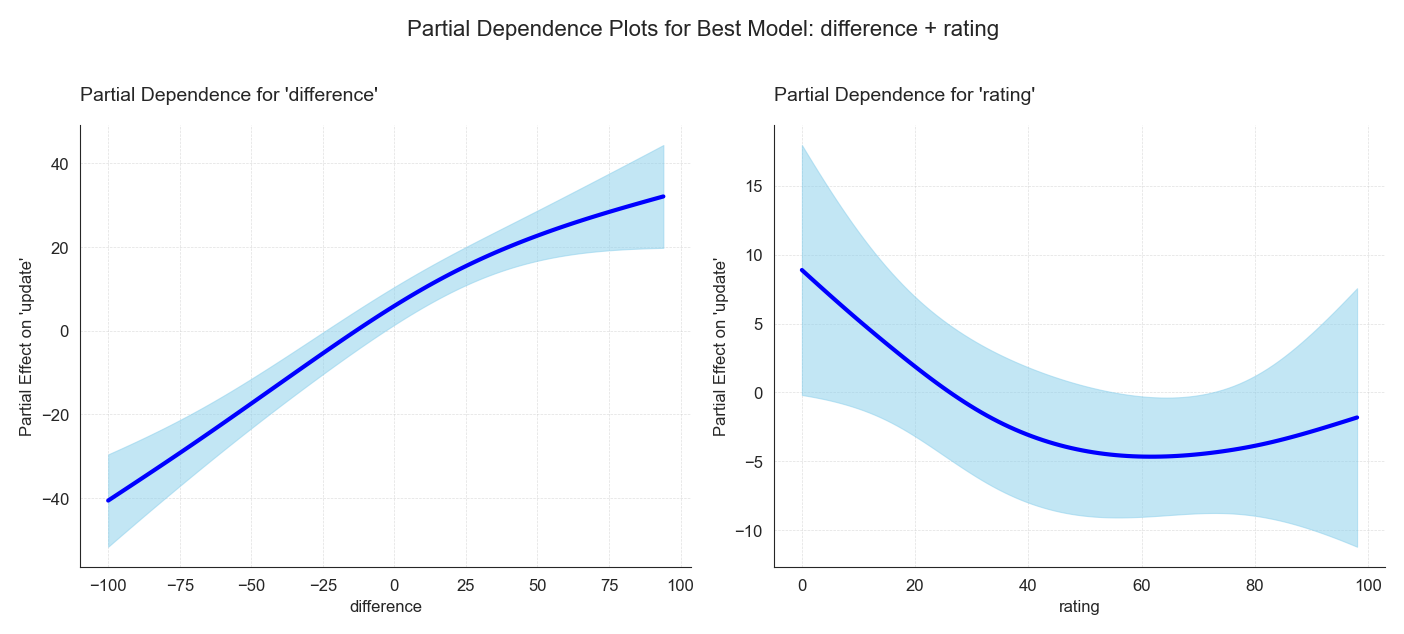


--- Best Model Summary (Trained on Training Data) ---
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      4.7632
Link Function:                     IdentityLink Log Likelihood:                                  -1346.034
Number of Samples:                          180 AIC:                                             2703.5943
                                                AICc:                                            2704.0443
                                                GCV:                                              740.2739
                                                Scale:                                            705.0986
                                                Pseudo R-Squared:                        

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pygam import LinearGAM, s, te
from sklearn.model_selection import train_test_split

df['update'] = df['post'] - df['pre']
df['difference'] = df['rating'] - df['pre']


train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
y_train = train_df['update'].values
y_test = test_df['update'].values


def analyze_and_find_best_model(train_df, y_train, test_df, y_test, models_to_test):
    """
    For each model configuration:
    1. Tunes the model on the TRAINING data using gridsearch (optimizing GCV).
    2. Evaluates the tuned model on the TEST data using Correlation.
    3. Returns the model with the best TEST Correlation.
    """
    best_model = None
    best_correlation = -1.0 # Initialize with the lowest possible correlation
    best_model_info = {}

    model_results = {}

    for model_config in models_to_test:
        predictor_cols = model_config['predictors']
        interaction = model_config.get('interaction', False)

        if interaction:
            model_name = f"{predictor_cols[0]} * {predictor_cols[1]} (Interaction)"
            formula = te(0, 1, n_splines=[15, 15])
        else:
            model_name = " + ".join(predictor_cols)
            formula = s(0, n_splines=15) + s(1, n_splines=15)

        print("\n" + "="*50)
        print(f"--- Testing Model: {model_name} ---")

        X_train = train_df[predictor_cols].values
        X_test = test_df[predictor_cols].values

        # Step 1: Tune model on training data. Gridsearch internally uses GCV.
        gam = LinearGAM(formula)
        gam.gridsearch(X_train, y_train, progress=False)

        # Step 2: Evaluate the tuned model on the test data with Correlation.
        predictions = gam.predict(X_test)
        correlation = np.corrcoef(y_test, predictions)[0, 1]
        model_results[model_name] = correlation
        print(f"--> TEST CORRELATION: {correlation:.4f}")

        # Step 3: Check if this model is the best so far based on TEST CORRELATION.
        if correlation > best_correlation:
            best_correlation = correlation
            best_model = gam
            best_model_info = {
                'name': model_name,
                'predictors': predictor_cols,
                'interaction': interaction,
                'correlation': correlation
            }

    print("\n" + "="*50)
    # Sort by correlation descending
    sorted_results = sorted(model_results.items(), key=lambda item: item[1], reverse=True)
    for model_name, score in sorted_results:
        print(f"Model '{model_name}': {score:.4f}")

    return best_model, best_model_info

def plot_best_model(gam, model_info):
    """Visualizes the single best performing model."""
    print("\n" + "="*50)
    print(f"--- Visualizing Best Model: {model_info['name']} ---")

    titles = model_info['predictors']
    X_train = train_df[titles].values # Use original training data for visualization range

    if model_info['interaction']:
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')
        XX = gam.generate_X_grid(term=0, n=50, meshgrid=True)
        Z = gam.partial_dependence(term=0, X=XX, meshgrid=True)
        ax.plot_surface(XX[0], XX[1], Z, cmap='viridis', edgecolor='none')
        ax.set_xlabel(titles[0])
        ax.set_ylabel(titles[1])
        ax.set_zlabel("Partial Effect on 'update'")
        ax.set_title(f"Interaction Surface for Best Model: {model_info['name']}", fontsize=16)
        plt.show()
    else:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        for i, ax in enumerate(axes):
            XX = gam.generate_X_grid(term=i, n=100)
            pdep, conf_intervals = gam.partial_dependence(term=i, X=XX, width=.95)
            ax.plot(XX[:, i], pdep, color='blue', lw=3)
            ax.fill_between(XX[:, i], conf_intervals[:, 0], conf_intervals[:, 1], color='skyblue', alpha=0.5)
            ax.set_title(f"Partial Dependence for '{titles[i]}'", fontsize=14)
            ax.set_xlabel(titles[i], fontsize=12)
            ax.set_ylabel("Partial Effect on 'update'", fontsize=12)
            ax.grid(True, linestyle='--', alpha=0.6)
        plt.suptitle(f"Partial Dependence Plots for Best Model: {model_info['name']}", fontsize=16, y=1.02)
        plt.tight_layout()
        plt.show()


# Define all models to be tested
models_to_test = [
    # Additive models
    {'predictors': ['pre', 'rating'], 'interaction': False},
    {'predictors': ['difference', 'pre'], 'interaction': False},
    {'predictors': ['difference', 'rating'], 'interaction': False},
    # Interaction models
    {'predictors': ['pre', 'rating'], 'interaction': True},
    {'predictors': ['difference', 'pre'], 'interaction': True},
    {'predictors': ['difference', 'rating'], 'interaction': True}
]

best_gam, best_model_info = analyze_and_find_best_model(train_df, y_train, test_df, y_test, models_to_test)

if best_gam:
    print("\n" + "="*50)
    print(f"--- Final Report for Best Model: '{best_model_info['name']}' ---")
    print(f"This model was selected because it had the highest correlation on unseen test data.")
    print(f"Final Test Correlation: {best_model_info['correlation']:.4f}")

    plot_best_model(best_gam, best_model_info)
    print("\n--- Best Model Summary (Trained on Training Data) ---")
    best_gam.summary()

